In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import itertools
from torch.nn import functional as F

np.random.seed(42)
torch.manual_seed(42)

# go-mHC Class
class GeneralizedUnistochastic(nn.Module):
    def __init__(self, d, s, batch_size=1, orthonormal=True, init=torch.rand):
        super().__init__()
        self.d = d
        self.s = s
        self.batch_size = batch_size
        self.total_dim = d * s
        
        # Add a batch dimension: (batch_size, ds, ds)
        self.raw_u = nn.Parameter(init(
            self.batch_size, self.total_dim, self.total_dim, 
            dtype=torch.float32 if orthonormal else torch.complex64
        ))

    def get_unitary(self):
        # Batch-wise adjoint and matrix exponential
        ru = self.raw_u
        
        X = ru - ru.adjoint() 
        # Can instead do matrix exp, but that is worse for many reasons (stability, number of operations, etc.)
        # return torch.matrix_exp(X)
        
        # Cayley Transform
        I = torch.eye(self.total_dim, device=X.device).unsqueeze(0).expand(self.batch_size, -1, -1)
        U = torch.linalg.solve(I - X, I + X)
        return U

    def forward(self):
        U = self.get_unitary()
        
        # Reshape to (batch, d, s, d, s) -> (batch, d, d, s, s)
        blocks = U.view(self.batch_size, self.d, self.s, self.d, self.s).permute(0, 1, 3, 2, 4)
        
        # Sum across the internal s x s blocks for the whole batch
        bistochastic_matrices = torch.sum(torch.abs(blocks)**2, dim=(-2, -1)) / self.s
        
        return bistochastic_matrices
    
    
# get all nxn permutation matrices as a tensor of shape (n!, n, n)
def get_permutation_matrices(n):
    perms = list(itertools.permutations(range(n)))
    matrices = [torch.zeros(n, n).index_put_((torch.arange(n), torch.tensor(p)), torch.tensor(1.0)) for p in perms]
    return torch.stack(matrices)

# Sinkhorn normalization to make a matrix doubly stochastic (same as in mHC paper)
# Repeatedly normalize rows and columns until convergence (or max iterations)
def sinkhorn(M, num_iters=20):
    # check if M is already doubly stochastic
    if torch.allclose(M.sum(dim=-1), torch.ones(M.shape[0], M.shape[1]), atol=1e-8) and torch.allclose(M.sum(dim=-2), torch.ones(M.shape[0], M.shape[2]), atol=1e-8):
        return M
    # Works on [B, n, n]
    for _ in range(num_iters):
        M = abs(M)  # Ensure non-negativity
        M = M / M.sum(dim=-1, keepdim=True)  # Row
        M = M / M.sum(dim=-2, keepdim=True)  # Col
    return M

# Class that implements both mHC-lite and KromHC
# To do KromHC, you have multiple num_factors and N=2 (num_factors is log2 of the dimension of the matrix)
# To do mHC-lite, you have num_factors=1 and N=n (the dimension of the matrix)
class GeneralizedKromHC(nn.Module):
    def __init__(self, num_factors, N=3, batch_size=1):
        super().__init__()
        self.num_factors = num_factors
        self.N = N
        self.batch_size = batch_size
        
        # Precompute all N! permutation matrices
        perms = list(itertools.permutations(range(N)))
        self.num_perms = len(perms)
        
        perm_mats = torch.zeros((self.num_perms, N, N))
        for i, p in enumerate(perms):
            for row, col in enumerate(p):
                perm_mats[i, row, col] = 1.0
        self.register_buffer('perm_mats', perm_mats)

        # Logits for the convex combination
        self.coeffs = nn.Parameter(torch.randn(batch_size, num_factors, self.num_perms))

    def forward(self):
        weights = F.softmax(self.coeffs, dim=-1) 
        
        # Build factor matrices: (Batch, Num_Factors, N, N)
        factor_mats = (weights.view(self.batch_size, self.num_factors, self.num_perms, 1, 1) * self.perm_mats.view(1, 1, self.num_perms, self.N, self.N)).sum(dim=2)
        
        res = factor_mats[:, 0, :, :]
        
        for k in range(1, self.num_factors):
            mat = factor_mats[:, k, :, :]
            curr_dim = res.shape[1]
            
            res_expanded = res.view(self.batch_size, curr_dim, 1, curr_dim, 1)
            mat_expanded = mat.view(self.batch_size, 1, self.N, 1, self.N)
            
            res = (res_expanded * mat_expanded).reshape(
                self.batch_size, curr_dim * self.N, curr_dim * self.N
            )
        return res

## Can Ignore this

In [5]:
# --- Setup Parameters ---
n = 4
B = 100  # Batch size
num_epochs = 1500 # Reduced epochs since batching is faster/more stable
dataset_size = 100

sparsity = 0.9

# 1. Prepare Targets
P = get_permutation_matrices(n) # [N!, n, n]
# T = torch.stack([P[b % len(P)] + P[(b // len(P)) % len(P)] for b in range(B)])
T = sinkhorn(torch.rand(B, n, n)) # [B, n, n] target batch
# T = torch.stack([(P[b % len(P)] + P[(b // len(P)) % len(P)] + P[((b // len(P)) // len(P)) % len(P)])/3 for b in range(B)])
T = sinkhorn(T) 

X = torch.rand(B, dataset_size, n)  # Random initialization for W method
sparse_mask = (torch.rand_like(X) > sparsity).float()
X = X * sparse_mask.sum(dim=-1, keepdim=True)  # Apply sparsity mask to inputs
Y = torch.einsum('bij,bkj->bki', T, X)  # Target output for W method

noise = 0.01 * torch.randn_like(Y)
Y += noise

In [6]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
from torch.nn import functional as F

# 1. Configuration & Models setup
models = {
    "gu_1": GeneralizedUnistochastic(n, 1, B),
    "gu_2": GeneralizedUnistochastic(n, 2, B),
    "gu_3": GeneralizedUnistochastic(n, 3, B),
    "mhc_lite": GeneralizedKromHC(num_factors=1, N=n, batch_size=B),
}

# Add KromHC if conditions met
if int(np.log2(n)) == np.log2(n):
    models["kromhc"] = GeneralizedKromHC(num_factors=int(np.log2(n)), N=2, batch_size=B)

# Specialized initialization for mhc_lite
with torch.no_grad():
    models["mhc_lite"].coeffs.copy_(torch.randn(B, len(P), requires_grad=True).unsqueeze(1))

# 2. Optimizers and Tracking
criterion = nn.L1Loss()
optimizers = {
    name: optim.Adam([m] if isinstance(m, torch.Tensor) else m.parameters(), lr=0.01)
    for name, m in models.items()
}

# History containers
history = {name: [] for name in models.keys()}
all_errs = {name: torch.zeros((B, num_epochs)) for name in models.keys()}

print(f"Starting batch optimization for {B} matrices...")

# 3. Training Loop
for epoch in range(num_epochs):
    epoch_logs = []
    
    for name, model in models.items():
        opt = optimizers[name]
        opt.zero_grad()
        
        # --- Forward Pass Logic ---
        output = model()
        
        # compute tildeY = output @ X
        tildeY = torch.einsum('bij,bkj->bki', output, X)
            
        # --- Loss & Backprop ---
        # loss = criterion(output, T)
        loss = criterion(tildeY, Y)
        loss.backward()
        opt.step()
        
        # --- Logging ---
        history[name].append(loss.item())
        # Store MSE error batch-wise
        all_errs[name][:, epoch] = torch.mean((tildeY - Y)**2, dim=[1, 2]).detach()
        
        if epoch % 50 == 0 and name in ["alpha", "W", "gu_2"]:
            epoch_logs.append(f"{name.capitalize()}: {loss.item():.6f}")

    if epoch_logs:
        print(f"Epoch {epoch} | {' | '.join(epoch_logs)}")

Starting batch optimization for 100 matrices...
Epoch 0 | Gu_2: 0.037903
Epoch 50 | Gu_2: 0.007993
Epoch 100 | Gu_2: 0.007869
Epoch 150 | Gu_2: 0.007873
Epoch 200 | Gu_2: 0.007878
Epoch 250 | Gu_2: 0.007882
Epoch 300 | Gu_2: 0.007880
Epoch 350 | Gu_2: 0.007882
Epoch 400 | Gu_2: 0.007883
Epoch 450 | Gu_2: 0.007882
Epoch 500 | Gu_2: 0.007883
Epoch 550 | Gu_2: 0.007888
Epoch 600 | Gu_2: 0.007885
Epoch 650 | Gu_2: 0.007887
Epoch 700 | Gu_2: 0.007885
Epoch 750 | Gu_2: 0.007884
Epoch 800 | Gu_2: 0.007888
Epoch 850 | Gu_2: 0.007889
Epoch 900 | Gu_2: 0.007887
Epoch 950 | Gu_2: 0.007881
Epoch 1000 | Gu_2: 0.007885
Epoch 1050 | Gu_2: 0.007884
Epoch 1100 | Gu_2: 0.007884
Epoch 1150 | Gu_2: 0.007886
Epoch 1200 | Gu_2: 0.007886
Epoch 1250 | Gu_2: 0.007885
Epoch 1300 | Gu_2: 0.007886
Epoch 1350 | Gu_2: 0.007882
Epoch 1400 | Gu_2: 0.007884
Epoch 1450 | Gu_2: 0.007883


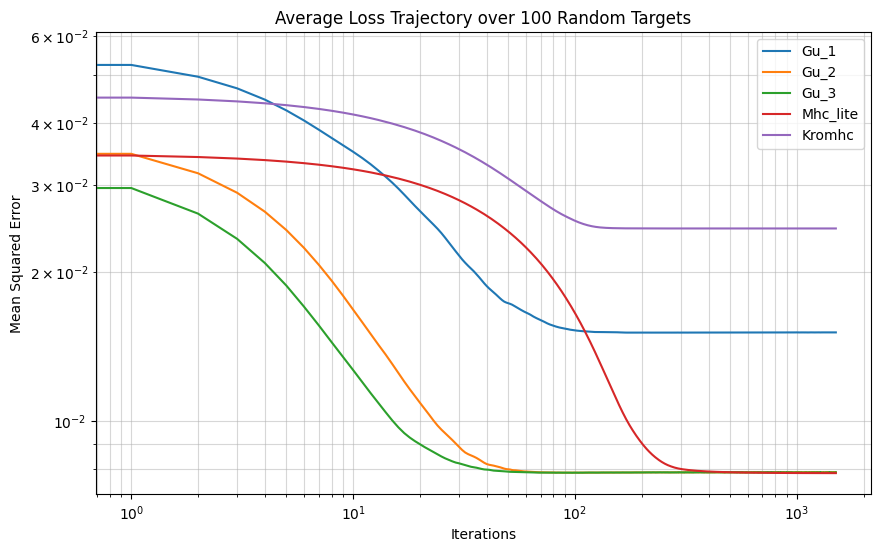

In [7]:
# Plotting the Average Loss
plt.figure(figsize=(10, 6))
for hist_name, hist_values in history.items():
    plt.plot(hist_values, label=hist_name.capitalize())

# plot 25-75 percentile error bands
# alpha_err_mean = all_alphas_err.mean(dim=0)
# alpha_err_std = all_alphas_err.std(dim=0)
# plt.fill_between(range(num_epochs), alpha_err_mean - alpha_err_std, alpha_err_mean + alpha_err_std, color='blue', alpha=0.2)
# w_err_mean = all_ws_err.mean(dim=0)
# w_err_std = all_ws_err.std(dim=0)
# plt.fill_between(range(num_epochs), w_err_mean - w_err_std, w_err_mean + w_err_std, color='orange', alpha=0.2)
# gu_err_mean = all_gus_err.mean(dim=0)
# gu_err_std = all_gus_err.std(dim=0)
# plt.fill_between(range(num_epochs), gu_err_mean - gu_err_std, gu_err_mean + gu_err_std, color='green', alpha=0.2)
# mhc_lite_err_mean = all_mhc_lite_err.mean(dim=0)
# mhc_lite_err_std = all_mhc_lite_err.std(dim=0)
# plt.fill_between(range(num_epochs), mhc_lite_err_mean - mhc_lite_err_std, mhc_lite_err_mean + mhc_lite_err_std, color='purple', alpha=0.2)
# kromhc_err_mean = all_kromhc_err.mean(dim=0)
# kromhc_err_std = all_kromhc_err.std(dim=0)
# plt.fill_between(range(num_epochs), kromhc_err_mean - kromhc_err_std, kromhc_err_mean + kromhc_err_std, color='brown', alpha=0.2)   

plt.yscale('log')
plt.xscale('log')
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.title(f"Average Loss Trajectory over {B} Random Targets")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

In [25]:
!pip install frozendict

  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
Using cached frozendict-2.4.7-py3-none-any.whl (16 kB)

[notice] A new release of pip is available: 24.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Parameter Sweeps

In [29]:
from functools import cache

import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# --- Core Experiment Function ---
import pickle
import os
from functools import wraps
from frozendict import frozendict


def file_cache(filename):
    """
    A decorator that caches the result of a function to a file.
    The cache persists across different runs of the program.
    Note: This simple version works best for functions with no arguments
    or if all calls use the same arguments, as it uses a single cache file.
    """
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            # A more robust implementation would use a key based on args/kwargs
            # in the filename if different inputs are expected.
            cache_file = filename 

            if len(args) > 1 or len(kwargs) > 0:
                raise NotImplementedError("This simple file cache only supports functions with a single argument (the config dict).")

            config = frozendict(args[0])

            if os.path.exists(cache_file):
                try: 
                    with open(cache_file, 'rb') as f:
                        print(f"Loading result from cache file: {cache_file}")

                        cached_data = pickle.load(f)
                        if config in cached_data:
                            return cached_data[config]
                except Exception as e:
                    print(f"Error loading cache: {e}. Recomputing.")
            else:
                cached_data = {}

            # If cache doesn't exist or failed to load, run the function
            result = func(*args, **kwargs)

            # Save the result to the cache file
            with open(cache_file, 'wb') as f:
                #instead of dumpting, add a value to dict with key config
                cached_data[config] = result
                pickle.dump(cached_data, f)
            
            print(f"Computed result and saved to cache file: {cache_file}")
            return result
        return wrapper
    return decorator

# Example Usage
@file_cache('toy_model_cache.pkl')
def run_single_experiment(config):
    """
    Runs one training session with a specific configuration.
    Returns the final metrics and history for plotting.
    """
    # 1. Setup local hyperparams from config
    n = config['n']
    B = config['B']
    lr = config['lr']
    sparsity = config['sparsity']
    num_epochs = config['num_epochs']
    dataset_size = config['dataset_size']
    noise_mag = config['noise_mag']
    
    include_H_pre = config['include_H_pre']  # Whether to include the pre_layer transformation in targets
    
    # 2. Data Generation (Target T and Inputs X)
    # Assuming get_permutation_matrices and sinkhorn are defined in your scope
    P = get_permutation_matrices(n)
    T = sinkhorn(torch.rand(B, n, n))
    # Y = T
    # T += (noise_mag * torch.rand_like(T))
    
    # T = abs(T)
    
    # X = T
    
    
    X = torch.rand(B, dataset_size, n)
    sparse_mask = (torch.rand_like(X) > sparsity).float()
    X = X * sparse_mask.sum(dim=-1, keepdim=True)
    Y = torch.einsum('bij,bkj->bki', T, X) + (noise_mag * torch.rand(B, dataset_size, n))
    
    if include_H_pre:
        pre_layer_target = torch.rand(1, n)  # Target for the pre_layer to learn
        Y = torch.einsum('ij,bkj->bki', pre_layer_target, Y)  # Apply the same pre_layer transformation to targets

    # 3. Model Initialization
    # You can expand this to test different model subsets
    exp_models = {
        "gu_1": GeneralizedUnistochastic(n, 1, B),
        "gu_2": GeneralizedUnistochastic(n, 2, B),
        "gu_3": GeneralizedUnistochastic(n, 3, B),
   
    }

    if n < 7:
        exp_models["mhc_lite"] = GeneralizedKromHC(num_factors=1, N=n, batch_size=B)
    
    if int(np.log2(n)) == np.log2(n):
        exp_models["kromhc"] = GeneralizedKromHC(num_factors=int(np.log2(n)), N=2, batch_size=B)
    
    if include_H_pre:
        # create a 1xn layer initialized to all 1s for each model
        pre_layer_init = torch.ones(1, n) + 0.1*torch.randn(1, n)
        pre_layer = {i: nn.Parameter(pre_layer_init.clone(), requires_grad=True) for i in exp_models.keys()}

    # 4. Optimization Setup
    criterion = nn.MSELoss()
    adam_params = dict(lr=lr)
    if include_H_pre:
        optimizers = {
            name: optim.Adam([{'params': m.parameters()}, {'params': pre_layer[name]}], **adam_params) for name, m in exp_models.items()
        }
    else:
        optimizers = {
            name: optim.Adam(m.parameters(), **adam_params) for name, m in exp_models.items()
        }
    
    # 5. Training Loop
    local_history = {name: np.zeros(num_epochs) for name in exp_models.keys()}
    
    for epoch in range(num_epochs):
        for name, model in exp_models.items():
            opt = optimizers[name]
            opt.zero_grad()
            
            output = model()
            tildeY = torch.einsum('bij,bkj->bki', output, X)
            
            # set tildeY to be pre_layer[name] @ tildeY
            if include_H_pre:
                tildeY = torch.einsum('ij,bkj->bki', pre_layer[name], tildeY)
            
            loss = criterion(tildeY, Y)
            # loss = criterion(Y, model())
            loss.backward()
            opt.step()
            
            local_history[name][epoch] = loss.item()
            
    # Return final loss for each model as a summary
    summary = {f"final_loss_{k}": v[-1] for k, v in local_history.items()}
    return summary, local_history

In [65]:
# fix seeds
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

sweep_config = {
    'n': [2, 3, 4, 5, 6, 7, 8, 10],
    #fig 8: 'n': [2, 3, 4, 5, 6, 7, 8, 10],

    'lr': [0.001],#, 0.005],
    'sparsity': [0],#, 0.5, 0.9, 0.99], sweep sparsity at d=4, plot loss relative to sparsity to show if method might be applicable beyond residual stream in sparse networks, or regenerate sparsity 
    'B': [64],
    'num_epochs': [10000],
    'dataset_size': [100],
    "noise_mag": [1e-1],# 1e-6 for , 1e-3, 1e-1]
    "include_H_pre": [False], # Whether to include the pre_layer transformation in targets
}

# Generate all combinations
keys, values = zip(*sweep_config.items())
experiments = [dict(zip(keys, v)) for v in product(*values)]

print(f"Total experiments to run: {len(experiments)}")

# --- Execution ---
all_results = []
all_histories = {}
for i, config in enumerate(experiments):
    print(f"Running Experiment {i+1}/{len(experiments)}: {config}")
    summary, hist = run_single_experiment(config)
    
    # Merge config and summary for a flat row
    result_row = {**config, **summary}
    all_results.append(result_row)
    all_histories[i] = hist

print("Sweep Complete!")

Total experiments to run: 8
Running Experiment 1/8: {'n': 2, 'lr': 0.001, 'sparsity': 0, 'B': 64, 'num_epochs': 10000, 'dataset_size': 100, 'noise_mag': 0.1, 'include_H_pre': False}
Loading result from cache file: toy_model_cache.pkl
Running Experiment 2/8: {'n': 3, 'lr': 0.001, 'sparsity': 0, 'B': 64, 'num_epochs': 10000, 'dataset_size': 100, 'noise_mag': 0.1, 'include_H_pre': False}
Loading result from cache file: toy_model_cache.pkl
Running Experiment 3/8: {'n': 4, 'lr': 0.001, 'sparsity': 0, 'B': 64, 'num_epochs': 10000, 'dataset_size': 100, 'noise_mag': 0.1, 'include_H_pre': False}
Loading result from cache file: toy_model_cache.pkl
Running Experiment 4/8: {'n': 5, 'lr': 0.001, 'sparsity': 0, 'B': 64, 'num_epochs': 10000, 'dataset_size': 100, 'noise_mag': 0.1, 'include_H_pre': False}
Loading result from cache file: toy_model_cache.pkl
Running Experiment 5/8: {'n': 6, 'lr': 0.001, 'sparsity': 0, 'B': 64, 'num_epochs': 10000, 'dataset_size': 100, 'noise_mag': 0.1, 'include_H_pre': F

In [12]:
# Loss Trajectories by # of residual streams and sparsity

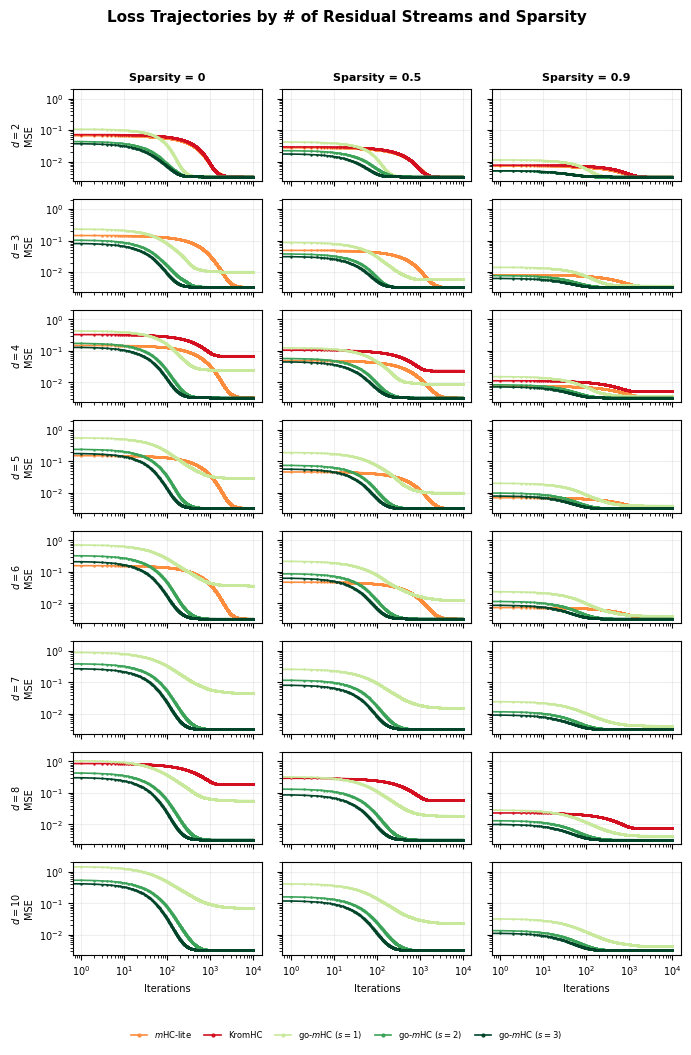

In [63]:
import matplotlib.pyplot as plt
import numpy as np

COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH * 2, COLUMN_WIDTH * 3)  # 3 cols x 8 rows

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "lines.linewidth": 1.2,
    "figure.autolayout": False
})


colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3))]

n_values = sweep_config['n']       # [2, 3, 4, 5, 6, 7, 8, 10]
sparsity_values = sweep_config['sparsity']  # [0, 0.5, 0.9]

n_rows = len(n_values)      # 8
n_cols = len(sparsity_values)  # 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=FIG_SIZE, sharex=True, sharey=True)

fig.suptitle("Loss Trajectories by # of Residual Streams and Sparsity",
             fontsize=11, fontweight='bold')

for col, s in enumerate(sparsity_values):
    axes[0, col].set_title(f"Sparsity = {s}", fontsize=8, fontweight='bold')


for row, (n_idx, d) in enumerate(enumerate(n_values)):
    for col, (s_idx, s) in enumerate(enumerate(sparsity_values)):
        #sparsity_multiplier = 1/(1 - sweep_config['sparsity'][col])

        ax = axes[row, col]
        exp_idx = n_idx * len(sparsity_values) + s_idx

        histories = {
            '$m$HC-lite': [],
            'KromHC': [],
            ' ': [],
            'go-$m$HC ($s=1$)': all_histories[exp_idx].get('gu_1', []),
            'go-$m$HC ($s=2$)': all_histories[exp_idx].get('gu_2', []),
            'go-$m$HC ($s=3$)': all_histories[exp_idx].get('gu_3', []),
        }
        if d.bit_count() == 1:
            histories['KromHC'] = all_histories[exp_idx].get('kromhc', [])
        if d < 7:
            histories['$m$HC-lite'] = all_histories[exp_idx].get('mhc_lite', [])

        i = 0
        for label in histories:
            #data = sparsity_multiplier * np.array(histories[label])

            data = histories[label]
            if data is not None and (hasattr(data, '__len__') and len(data) > 0):
                ax.plot(data, color=colors[i],
                        alpha=0 if label == " " else 1,
                        marker='.', markersize=1.5, rasterized=True)
            i += 1

        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.grid(True, which="major", ls="-", alpha=0.2)

        # Row label on leftmost column
        if col == 0:
            ax.set_ylabel(f"$d={d}$\nMSE", fontsize=7)

        # X-axis label on bottom row only
        if row == n_rows - 1:
            ax.set_xlabel("Iterations", fontsize=7)

# --- Single shared legend ---
# Build from the label/color mapping
from matplotlib.lines import Line2D

legend_labels = ['$m$HC-lite', 'KromHC', 'go-$m$HC ($s=1$)',
                 'go-$m$HC ($s=2$)', 'go-$m$HC ($s=3$)']
legend_colors = [colors[0], colors[1], colors[3], colors[4], colors[5]]

handles = [Line2D([0], [0], color=c, marker='.', markersize=4, lw=1.2, label=l)
           for c, l in zip(legend_colors, legend_labels)]

fig.legend(handles=handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.01),
           ncol=len(handles),
           frameon=False,
           fontsize=6,
           columnspacing=1.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('fig_loss_traj_sparsity_grid.pdf', bbox_inches='tight', dpi=300)
plt.show()

# MSE by matrix dimension

noise:  [0.1]


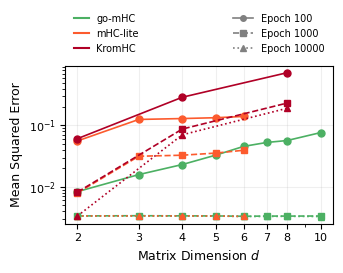

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.8)

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True
})

colors_methods = {
    'go-mHC': plt.cm.YlGn(0.6),
    'mHC-lite': plt.cm.YlOrRd(0.6),
    'KromHC': plt.cm.YlOrRd(0.9),
}
epoch_indices = [99, 999, 9999]
epoch_markers = {99: 'o', 999: 's', 9999: '^'}
epoch_linestyles = {99: '-', 999: '--', 9999: ':'}

dims = sweep_config['n']

def get_loss_at_epoch(history_list, epoch_idx):
    if history_list is None or (hasattr(history_list, '__len__') and len(history_list) == 0):
        return None
    if epoch_idx >= len(history_list):
        return None
    return history_list[epoch_idx]

fig, ax = plt.subplots(figsize=FIG_SIZE)

for method_name, method_key_fn in [
    ('go-mHC', lambda dim: all_histories[dim].get('gu_2', [])),
    ('mHC-lite', lambda dim: all_histories[dim].get('mhc_lite', [])),
    ('KromHC', lambda dim: all_histories[dim].get('kromhc', [])),
]:
    color = colors_methods[method_name]
    for epoch in epoch_indices:
        xs = []
        ys = []
        for dim_idx, d in enumerate(dims):
            hist = method_key_fn(dim_idx)
            if method_name == 'KromHC' and d.bit_count() != 1:
                continue
            if method_name == 'mHC-lite' and d >= 7:
                continue
            val = get_loss_at_epoch(hist, epoch)
            if val is not None:
                xs.append(d)
                ys.append(val)
        if xs:
            ax.plot(xs, ys,
                    color=color,
                    marker=epoch_markers[epoch],
                    linestyle=epoch_linestyles[epoch],
                    markersize=5,
                    rasterized=True)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xticks(dims)
ax.set_xticklabels([str(d) for d in dims])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_xlabel("Matrix Dimension $d$")
ax.set_ylabel("Mean Squared Error")
ax.grid(True, which="major", ls="-", alpha=0.2)

# --- Two-column legend above the plot ---
method_handles = [
    Line2D([0], [0], color=colors_methods[m], lw=1.5, label=m)
    for m in ['go-mHC', 'mHC-lite', 'KromHC']
]
epoch_handles = [
    Line2D([0], [0], color='gray', marker=epoch_markers[e],
           linestyle=epoch_linestyles[e], lw=1.2, markersize=4, label=f'Epoch {e+1}')
    for e in epoch_indices
]

legend1 = ax.legend(handles=method_handles,
                    loc='lower left',
                    bbox_to_anchor=(0.0, 1.02),
                    ncol=1, frameon=False, fontsize=7,
                    handlelength=1.5)
legend2 = ax.legend(handles=epoch_handles,
                    loc='lower right',
                    bbox_to_anchor=(1.0, 1.02),
                    ncol=1, frameon=False, fontsize=7,
                    handlelength=2.0)
ax.add_artist(legend1)

print("noise: ", sweep_config['noise_mag'])

plt.savefig('fig_final_mse_vs_dim_high_noise.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Loss Trajectories by # of residual streams

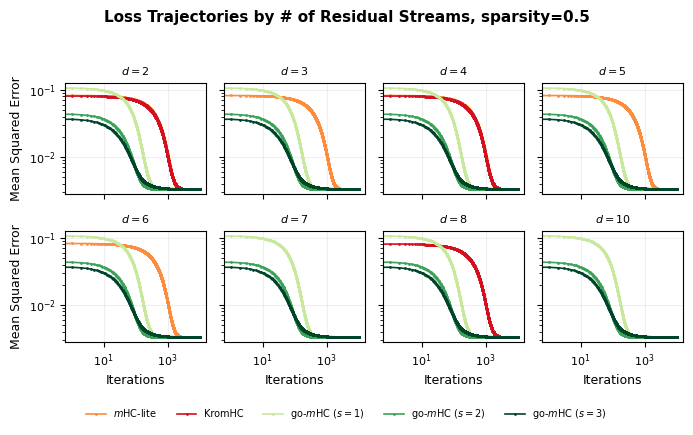

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5
FIG_SIZE = (COLUMN_WIDTH * 2, COLUMN_WIDTH * 1.2)  # wider for 4x2 grid

plt.rcParams.update({
    "text.usetex": False,
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": False  # we'll use tight_layout manually
})

colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3))]

fig, axes = plt.subplots(2, 4, figsize=FIG_SIZE, sharex=True, sharey=True)
axes = axes.flatten()

fig.suptitle("Loss Trajectories by # of Residual Streams, sparsity=0.5", fontsize=11, fontweight='bold')

for dim in range(len(sweep_config['n'])):
    ax = axes[dim]

    histories = {
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': all_histories[dim]['gu_1'],
        'go-$m$HC ($s=2$)': all_histories[dim]['gu_2'],
        'go-$m$HC ($s=3$)': all_histories[dim]['gu_3']
    }
    if sweep_config['n'][dim].bit_count() == 1:
        histories['KromHC'] = all_histories[dim]['kromhc']
    if sweep_config['n'][dim] < 7:
        histories['$m$HC-lite'] = all_histories[dim]['mhc_lite']

    i = 0
    for label in histories:
        data = histories[label]
        ax.plot(data, label=label, color=colors[i],
                alpha=0 if label == " " else 1, marker='.', markersize=2, rasterized=True)
        i += 1

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_title(f"$d={sweep_config['n'][dim]}$", fontsize=8)
    ax.grid(True, which="major", ls="-", alpha=0.2)

    # Only label outer axes
    if dim >= 4:
        ax.set_xlabel("Iterations")
    if dim % 4 == 0:
        ax.set_ylabel("Mean Squared Error")

# Single shared legend from the last subplot's handles
handles, labels = axes[-1].get_legend_handles_labels()
# Filter out the blank spacer entry
filtered = [(h, l) for h, l in zip(handles, labels) if l.strip()]
fig.legend(*zip(*filtered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=len(filtered),
           frameon=False,
           fontsize=7,
           columnspacing=2)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('appendix_loss_trajectories_mid_sparsity.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Single Loss Curve

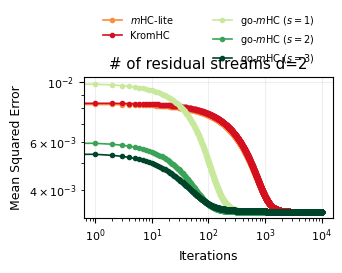

KeyboardInterrupt: 

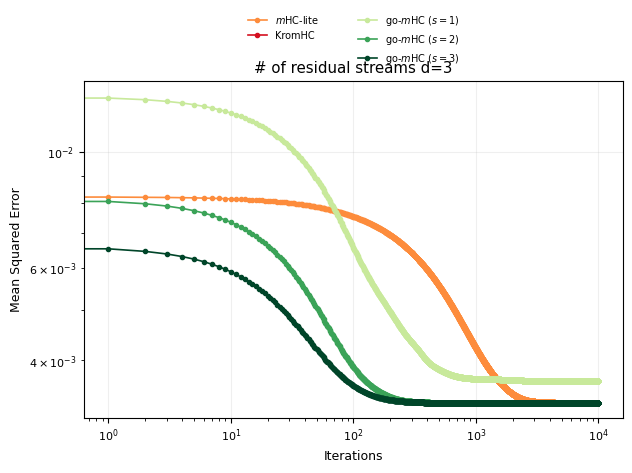

In [68]:
import matplotlib.pyplot as plt

# --- ICML Styling Constants ---
COLUMN_WIDTH = 3.5  
FIG_SIZE = (COLUMN_WIDTH, COLUMN_WIDTH * 0.8)

plt.rcParams.update({
    "text.usetex": False,            
    # "font.family": "serif",
    # "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 9,                 
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True       
})

plt.figure(figsize=FIG_SIZE)

# Use a consistent color palette
# colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628', '#984ea3', '#999999']

# colors = [*plt.cm.YlGn([0.5, 0.8]), "k", *plt.cm.YlOrRd(np.linspace(0.3, 1, 3))]
colors = [*plt.cm.YlOrRd([0.5, 0.8]), "k", *plt.cm.YlGn(np.linspace(0.3, 1, 3))]

# Data mapping for easier iteration
for dim in range(len(sweep_config['n'])):
    histories = {
        # 'n! Parameters': hist_alpha,
        '$m$HC-lite': [],
        'KromHC': [],
        ' ': [],
        'go-$m$HC ($s=1$)': all_histories[dim]['gu_1'],
        'go-$m$HC ($s=2$)': all_histories[dim]['gu_2'],
        'go-$m$HC ($s=3$)': all_histories[dim]['gu_3']
    }
    if sweep_config['n'][dim].bit_count()==1:
        histories['KromHC']=all_histories[dim]['kromhc']
    
    if sweep_config['n'][dim] < 7:
        histories['$m$HC-lite']=all_histories[dim]['mhc_lite']
       

    #color_dict={mhc_lite=}
    # Plotting with refined styles

    i=0
    for label in histories:
        data=histories[label]
        plt.plot(data, label=label, color=colors[i], alpha=0 if label==" " else 1, marker='.', rasterized=True)
        i+=1

    plt.yscale('log')
    plt.xscale('log')

    #np.logspace(0, 4, 101, dtype=int)

    plt.title("# of residual streams d="+str(sweep_config['n'][dim]))
    plt.xlabel("Iterations")
    plt.ylabel("Mean Squared Error")

    # Minimal grid for better readability in print
    plt.grid(True, which="major", ls="-", alpha=0.2)

    # Legend placed above to avoid covering convergence trajectories
    plt.legend(loc='lower center', 
            bbox_to_anchor=(0.5, 1.02), 
            ncol=2, 
            frameon=False, 
            fontsize=7, columnspacing=4)

    # plt.ylim(10**(-4.5))
    plt.savefig('fig_9_loss_trajectory_1.pdf', bbox_inches='tight', dpi=300)
    plt.show()


In [56]:
# reset rcParams to default before applying new style
plt.rcParams.update(plt.rcParamsDefault)

# ICML figure styling with one col (3.25in width)
plt.rcParams.update({
    'font.size': 10,
    'figure.figsize': (3.25, 2.5),
    'lines.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'legend.loc': 'upper right',
})

In [57]:
# plot the two KromHC (include H_pre vs not) on the same plot for comparison
kromhc_hist_without_pre = all_histories[0]['kromhc']
kromhc_hist_with_pre = all_histories[1]['kromhc']

color_KromHC = plt.cm.YlOrRd(0.8)

plt.figure()
plt.plot(kromhc_hist_with_pre, label="KromHC with $\mathcal{H}^\mathrm{pre}$", color=color_KromHC, linestyle='--')
plt.plot(kromhc_hist_without_pre, label="KromHC without $\mathcal{H}^\mathrm{pre}$", color=color_KromHC)

# shade the area between the two curves after they cross to highlight the difference
crossing_points = np.where(np.diff(np.sign(kromhc_hist_with_pre - kromhc_hist_without_pre)))[0]
if len(crossing_points) > 0:
    last_crossing = crossing_points[-1]
    plt.fill_between(range(last_crossing, len(kromhc_hist_with_pre)), kromhc_hist_with_pre[last_crossing:], kromhc_hist_without_pre[last_crossing:], color='tab:orange', alpha=0.3)
    
    # add annotation in the middle of region "Advantage of $\mathcal{H}^\mathrm{pre}$"
    mid_point = last_crossing + (len(kromhc_hist_with_pre) - last_crossing) // 2
    # plt.annotate("$\mathcal{H}^\mathrm{pre}$ Symmetry Breaking", xy=(mid_point, (kromhc_hist_with_pre[mid_point] + kromhc_hist_without_pre[mid_point]) / 2), xytext=(mid_point, (kromhc_hist_with_pre[mid_point] + kromhc_hist_without_pre[mid_point]) / 2 * 5), arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, ha='center')
    plt.text(mid_point + 500, (kromhc_hist_with_pre[mid_point] + kromhc_hist_without_pre[mid_point]) / 2 / 1.5, "Advantage of $\mathcal{H}^\mathrm{pre}$", fontsize=10, ha='center')

plt.yscale('log')
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.legend()
# plt.title("KromHC Loss Trajectory Comparison")
plt.grid(True, which="major", ls="-", alpha=0.5)
# remove minor grid
plt.minorticks_off()
plt.savefig("kromhc_symmetry_breaking_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

KeyError: 1

In [ ]:
import pandas as pd
df = pd.DataFrame(all_results)
# set max width of print to fit entire table
pd.set_option('display.max_columns', None)
print(df.sort_values(by='final_loss_mhc_lite'))

   n     lr  sparsity   B  num_epochs  dataset_size  noise_mag  include_H_pre  \
1  4  0.001         0  64       10000           100        0.1           True   
0  4  0.001         0  64       10000           100        0.1          False   

   final_loss_gu_2  final_loss_mhc_lite  final_loss_kromhc  
1         0.002491             0.002502           0.013217  
0         0.003323             0.003326           0.071619  


# Weird Circuit Model

In [87]:
import sympy
import numpy as np

a, b = sympy.symbols('a b')
A, B = np.array([[a, 1-a], [1-a, a]]), np.array([[b, 1-b], [1-b, b]])

# A tensor B to get a 4x4 matrix
Hres = np.kron(A, B)

Hres

array([[a*b, a*(1 - b), b*(1 - a), (1 - a)*(1 - b)],
       [a*(1 - b), a*b, (1 - a)*(1 - b), b*(1 - a)],
       [b*(1 - a), (1 - a)*(1 - b), a*b, a*(1 - b)],
       [(1 - a)*(1 - b), b*(1 - a), a*(1 - b), a*b]], dtype=object)

In [176]:
# cyclic permutation matrix for 4 elements
target = np.array([[0, 0.1, 0, 0.9],
                   [0.5, 0.4, 0, 0],
                   [0.5, 0.4, 0, 0.1],
                   [0, 0, 1, 0]])

target

array([[0. , 0.1, 0. , 0.9],
       [0.5, 0.4, 0. , 0. ],
       [0.5, 0.4, 0. , 0.1],
       [0. , 0. , 1. , 0. ]])

In [177]:
# make a system of equations from Hres, target
H = sympy.Matrix(Hres - target)

# solve for a, b
solution = sympy.solve(H, (a, b))
solution

[]

In [178]:
v = np.array([sympy.Symbol(f"v_{i}") for i in range(4)])

sympy.Matrix(v @ Hres) #.subs({v[0]: 1, v[1]: 0, v[2]: 0, v[3]: 1})

Matrix([
[a*b*v_0 + a*v_1*(1 - b) + b*v_2*(1 - a) + v_3*(1 - a)*(1 - b)],
[a*b*v_1 + a*v_0*(1 - b) + b*v_3*(1 - a) + v_2*(1 - a)*(1 - b)],
[a*b*v_2 + a*v_3*(1 - b) + b*v_0*(1 - a) + v_1*(1 - a)*(1 - b)],
[a*b*v_3 + a*v_2*(1 - b) + b*v_1*(1 - a) + v_0*(1 - a)*(1 - b)]])

In [189]:
w = np.array([sympy.Symbol(f"w_{i}") for i in range(4)])

# w[3:] = 0

# make a system of equations from Hres, target
H = sympy.Matrix(v @ Hres - w @ target)

solution = sympy.solve(H, (v[0], v[1], v[2], v[3], w[0], w[1], w[2], w[3]))
solution

{v_0: w_0*(10.0*a*b - 10.0*a - 9.0*b + 9.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_1*(9.0*a*b - 4.0*a)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_2*(10.0*a*b - 5.0*a - b + 1.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_3*(a*b - b)/(4.0*a*b - 2.0*a - 2.0*b + 1.0),
 v_1: w_0*(10.0*a*b - 9.0*b)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_1*(9.0*a*b - 5.0*a)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_2*(10.0*a*b - 5.0*a - b)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_3*(a*b - a - b + 1.0)/(4.0*a*b - 2.0*a - 2.0*b + 1.0),
 v_2: a*b*w_3/(4.0*a*b - 2.0*a - 2.0*b + 1.0) + w_0*(10.0*a*b - 10.0*a - b + 1.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_1*(9.0*a*b - 4.0*a - 9.0*b + 4.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_2*(10.0*a*b - 5.0*a - 9.0*b + 4.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0),
 v_3: w_0*(10.0*a*b - b)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_1*(9.0*a*b - 5.0*a - 9.0*b + 5.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_2*(10.0*a*b - 5.0*a - 9.0*b + 5.0)/(40.0*a*b - 20.0*a - 20.0*b + 10.0) + w_3*(a*b - 

In [190]:
solution[v[0]].simplify()#.factor(a, b)

(40.0*a*b*w_0 + 36.0*a*b*w_1 + 40.0*a*b*w_2 + 40.0*a*b*w_3 - 40.0*a*w_0 - 16.0*a*w_1 - 20.0*a*w_2 - 36.0*b*w_0 - 4.0*b*w_2 - 40.0*b*w_3 + 36.0*w_0 + 4.0*w_2)/(160.0*a*b - 80.0*a - 80.0*b + 40.0)

In [187]:
solution[v[2]].simplify()#.factor(a, b)

(10.0*a*b*w_2 + 10.0*a*b*w_3 - 5.0*a*w_2 - 9.0*b*w_2 + w_0*(10.0*a*b - 10.0*a - b + 1.0) + w_1*(9.0*a*b - 4.0*a - 9.0*b + 4.0) + 4.0*w_2)/(40.0*a*b - 20.0*a - 20.0*b + 10.0)

In [ ]:
solution

array([[0, 0, 0, 1],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0]])

In [129]:
v @ Hres

array([a*b*v_0 + a*v_1*(1 - b) + b*v_2*(1 - a) + v_3*(1 - a)*(1 - b),
       a*b*v_1 + a*v_0*(1 - b) + b*v_3*(1 - a) + v_2*(1 - a)*(1 - b),
       a*b*v_2 + a*v_3*(1 - b) + b*v_0*(1 - a) + v_1*(1 - a)*(1 - b),
       a*b*v_3 + a*v_2*(1 - b) + b*v_1*(1 - a) + v_0*(1 - a)*(1 - b)],
      dtype=object)

In [ ]:
sympy.Matrix(v @ Hres).subs({v[0]: 1, v[1]: 0, v[2]: 0, v[3]: 0})

Matrix([
[            a*b],
[      a*(1 - b)],
[      b*(1 - a)],
[(1 - a)*(1 - b)]])

In [109]:
sympy.Matrix(v @ Hres).subs({v[0]: 0, v[1]: 0, v[2]: 0, v[3]: 1})

Matrix([
[(1 - a)*(1 - b)],
[      b*(1 - a)],
[      a*(1 - b)],
[            a*b]])

In [111]:
# Compare it with the explicit read at 1 and 3 matrix
R13 = np.array([1, 0, 0, 1])

sympy.Matrix(R13 @ Hres)

Matrix([
[a*b + (1 - a)*(1 - b)],
[a*(1 - b) + b*(1 - a)],
[a*(1 - b) + b*(1 - a)],
[a*b + (1 - a)*(1 - b)]])